# Test open nanosurf data (nid)

In [ ]:
import os

folder_path = ".\Leuven"
all_entries = os.listdir(folder_path)
file_names = [
    f for f in all_entries
    if os.path.isfile(os.path.join(folder_path, f))
]
file_names = file_names[1:]

slot_14 = file_names[:len(file_names)//2]
slot_18 = file_names[len(file_names)//2:]

: 

In [ ]:
from NSFopen.read import nid_read
import numpy as np
from scipy.signal import correlate
import matplotlib.pyplot as plt

Axis = [0,35,70,105,140,-35,-70,-105,-140]
path = "./Leuven/"
profiles_mean = []
profiles_std = []
i=0

for file in slot_14:
    i=i+1

    if i>9:
        scandirection = 'X'
        Coordinates = "({},0)".format(Axis[i-10])
    else:
        scandirection = 'Y'
        Coordinates = "(0,{})".format(Axis[i-1])

    filepath = path + file
    print(filepath,Coordinates)
    afm = nid_read(filepath)

    data = afm.data
    # param = afm.param

    Forward_image = data['Image']['Forward']['Z-Axis Sensor']
    left = 20
    right = 115
    data = Forward_image[left:right, :]

    # plt.imshow(data,cmap='afmhot')
    # plt.title('AFM Topography', fontsize=12)
    # plt.show()

    # plt.plot(Forward_image[:, 0])
    # plt.grid(True)
    # plt.tight_layout()
    # plt.axvline(x=left, color='red', linestyle='--')
    # plt.axvline(x=right, color='red', linestyle='--')
    # plt.ylabel('Height (um)')
    # plt.xlabel('Profile Points')
    # plt.show()

    y = []
    for row in range(data.shape[0]):
        y.extend(data[-row-1, :]*1e6) 
        
    Image_size = 20
    Image_unit = 'um'
    Points = len(y)
    x = np.linspace(0, Image_size, Points)

    plt.plot(x, y)
    plt.grid(True)
    plt.tight_layout()
    plt.ylabel('Height (um)')
    plt.xlabel('Profile Scan (um)')
    plt.title('Profile Scan, '+scandirection+' Axis Scanning: ' + Coordinates)
    plt.show()

    profiles_mean.append(np.mean(y))
    profiles_std.append(np.std(y))



: 

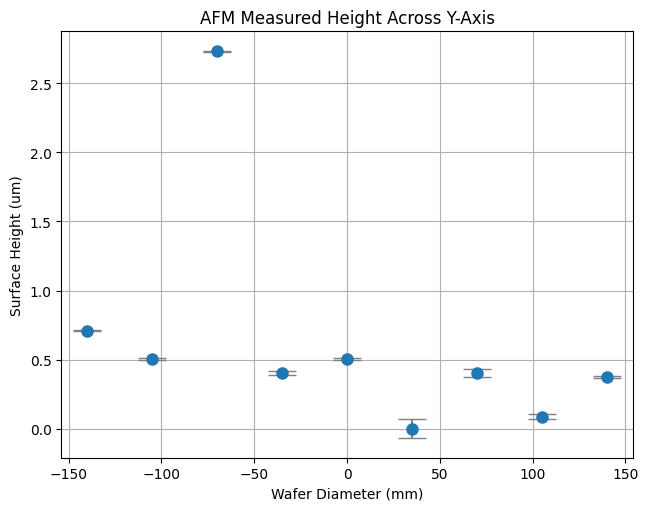

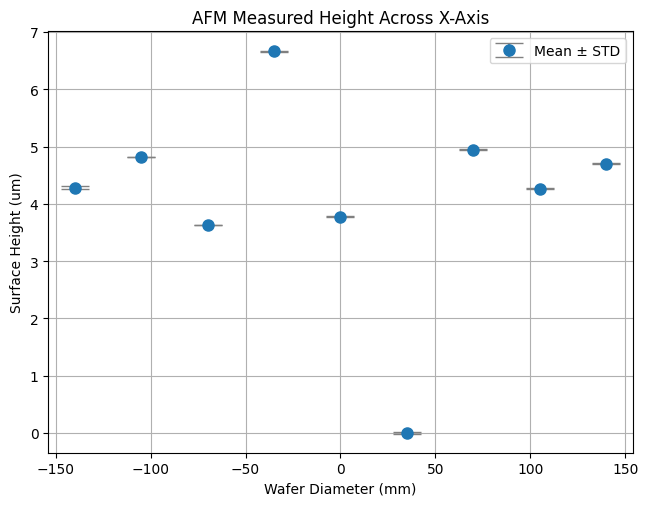

profiles_mean_on_X:  0.6369090534404044 STD is  1.3241890604468838


In [ ]:
Axis = [0,35,70,105,140,-35,-70,-105,-140]
profiles_mean_on_Y = profiles_mean[:len(profiles_mean)//2]
profiles_mean_on_X = profiles_mean[len(profiles_mean)//2:]
profiles_std_on_Y = profiles_std[:len(profiles_std)//2]
profiles_std_on_X = profiles_std[len(profiles_std)//2:]

profiles_mean_on_Y = profiles_mean_on_Y - np.min(profiles_mean_on_Y)
profiles_mean_on_X = profiles_mean_on_X - np.min(profiles_mean_on_X)

plt.errorbar(
    Axis,                     
    profiles_mean_on_Y,        
    yerr=profiles_std_on_Y,
    fmt='o', 
    markersize=8,
    ecolor='gray', 
    capsize=10,   
    label='Mean ± STD'               
)
plt.grid(True)
plt.tight_layout()
plt.ylabel('Surface Height (um)')
plt.xlabel('Wafer Diameter (mm)')
plt.title('AFM Measured Height Across Y-Axis')
plt.show()

plt.errorbar(
    Axis,                     
    profiles_mean_on_X,        
    yerr=profiles_std_on_X,
    fmt='o', 
    markersize=8,
    ecolor='gray', 
    capsize=10,
    label='Mean ± STD'                
)
plt.grid(True)
plt.tight_layout()
plt.ylabel('Surface Height (um)')
plt.xlabel('Wafer Diameter (mm)')
plt.title('AFM Measured Height Across X-Axis')
plt.legend()
plt.show()

print("profiles_mean_on_X: ",np.mean(profiles_mean), "STD is ",np.std(profiles_mean))
